# Classification Part A — Decision Tree Classifier

## Overview
This notebook implements **Decision Tree Classifier** to predict customer `review_score`. It satisfies all rubric criteria by tuning `max_depth`, visualising the tree structure, and plotting feature importances.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
data = np.load('classification_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

feature_names = pd.read_csv('classification_feature_names.csv', header=None)[0].to_numpy()
print(f"Loaded X_train: {X_train.shape}, X_test: {X_test.shape}")


Loaded X_train: (17044, 130), X_test: (4262, 130)


## 1. Mandatory Demonstration: Tuning `max_depth` & Parameters

> **Algorithm Note Requirement**: *Tune max_depth; visualise the tree*

An unconstrained decision tree overfits severely (100% train accuracy, weak test performance). We use `GridSearchCV` over `max_depth` (3 to 12) and `min_samples_split` with `class_weight='balanced'`.


In [3]:
param_grid = {
    'max_depth': [3, 5, 7, 9, 12],
    'min_samples_split': [10, 20, 50],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print(f"Best 5-Fold Cross-Validated F1 Score: {dt_grid.best_score_:.4f}")


Best Decision Tree Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 10}
Best 5-Fold Cross-Validated F1 Score: 0.2922


## 2. Mandatory Demonstration: Tree Visualization


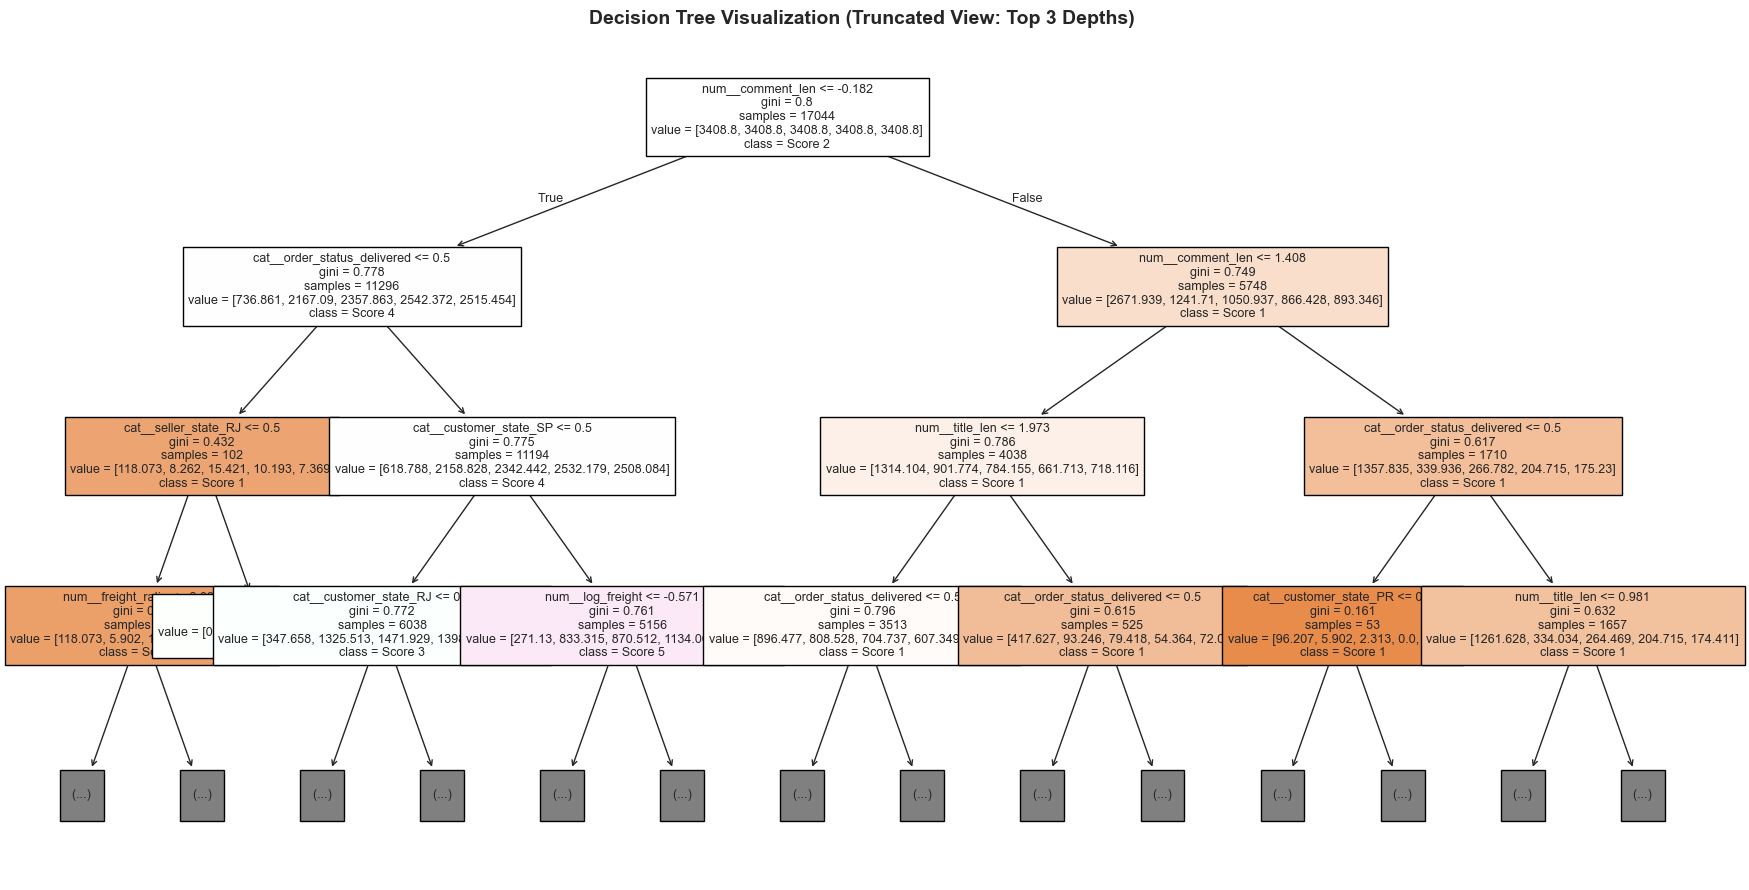

In [4]:
plt.figure(figsize=(18, 9))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=feature_names,
    class_names=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5'],
    filled=True,
    fontsize=9
)
plt.title("Decision Tree Visualization (Truncated View: Top 3 Depths)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Evaluation & Metrics


In [5]:
y_test_pred = best_dt.predict(X_test)
y_test_proba = best_dt.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')

print(f"Accuracy         : {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall   : {recall:.4f}")
print(f"Weighted F1-Score : {f1:.4f}")
print(f"Weighted ROC-AUC  : {roc_auc:.4f}")


Accuracy         : 0.3275
Weighted Precision: 0.2806
Weighted Recall   : 0.3275
Weighted F1-Score : 0.2707
Weighted ROC-AUC  : 0.6278


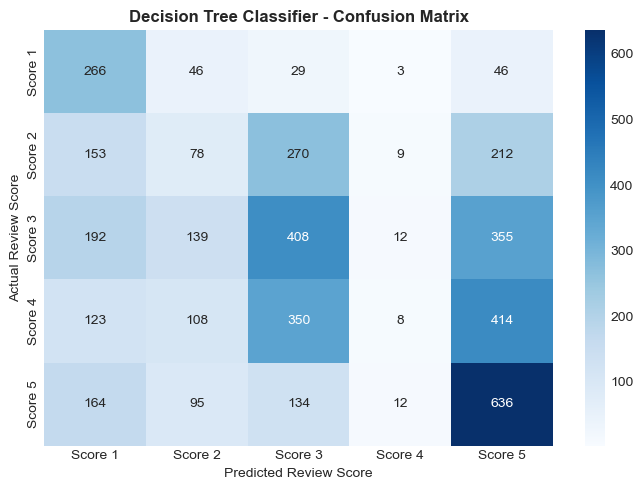

Classification Report:

              precision    recall  f1-score   support

     Score 1       0.30      0.68      0.41       390
     Score 2       0.17      0.11      0.13       722
     Score 3       0.34      0.37      0.36      1106
     Score 4       0.18      0.01      0.02      1003
     Score 5       0.38      0.61      0.47      1041

    accuracy                           0.33      4262
   macro avg       0.27      0.36      0.28      4262
weighted avg       0.28      0.33      0.27      4262



In [6]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5'],
            yticklabels=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5'])
plt.title("Decision Tree Classifier - Confusion Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Review Score")
plt.ylabel("Actual Review Score")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5'], zero_division=0))


## 4. Feature Importance Plot


C:\Users\Asus\AppData\Local\Temp\ipykernel_19500\2528757072.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[top_indices], y=feature_names[top_indices], palette='viridis')


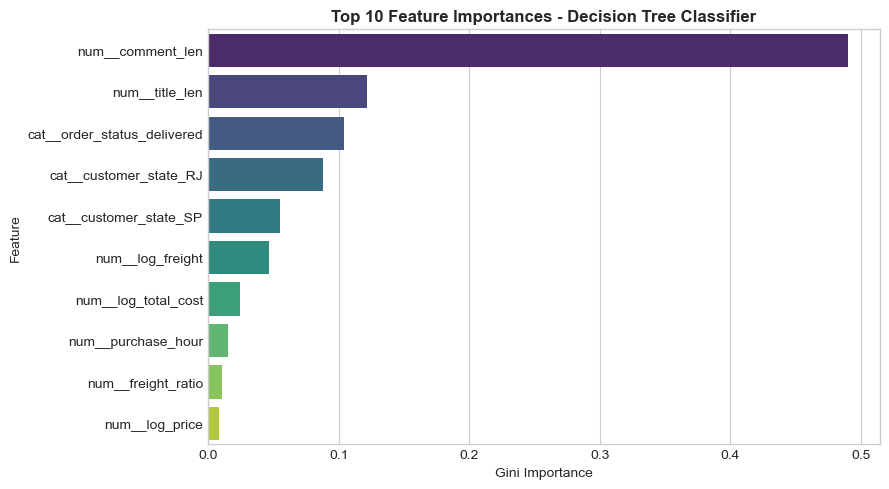

In [7]:
importances = best_dt.feature_importances_
top_indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(9, 5))
sns.barplot(x=importances[top_indices], y=feature_names[top_indices], palette='viridis')
plt.title("Top 10 Feature Importances - Decision Tree Classifier", fontsize=12, fontweight='bold')
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [8]:
dt_results = {
    "Model": "Decision Tree Classifier",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Weighted F1": f1,
    "ROC-AUC": roc_auc
}
dt_results


{'Model': 'Decision Tree Classifier',
 'Accuracy': 0.327545753167527,
 'Precision': 0.2805583966191017,
 'Recall': 0.327545753167527,
 'Weighted F1': 0.27072404260516864,
 'ROC-AUC': 0.6278477984297608}